# 06 — Full Results Comparison

Consolidated visualisation of all models and domain adaptation methods.

**Sections:**
1. Load data and all models
2. Summary metrics table
3. ROC + PR curves — all methods on MIMIC
4. Bar chart comparison (ROC-AUC, Sensitivity, Specificity)
5. Calibration plots — before and after label shift correction
6. Confusion matrices on MIMIC
7. SHAP feature importance (eICU training set)
8. Subgroup performance breakdown
9. Bootstrap confidence intervals — MIMIC external test
10. SHAP on MIMIC — feature importance shift vs eICU
11. Decision Curve Analysis — clinical utility

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!pip install -q shap xgboost torch imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, pickle
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import shap

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve

BASE      = '/content/drive/MyDrive/AI in Medicine/data/output_data/preprocessed'
MODEL_DIR = '/content/drive/MyDrive/AI in Medicine/models'
EXT_DIR   = f'{MODEL_DIR}/extensions'

SEED = 42
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data and Models

In [7]:
# ── Data
X_train = pd.read_csv(f'{BASE}/X_train.csv')
y_train = pd.read_csv(f'{BASE}/y_train.csv').squeeze()
X_val   = pd.read_csv(f'{BASE}/X_val.csv')
y_val   = pd.read_csv(f'{BASE}/y_val.csv').squeeze()
X_test  = pd.read_csv(f'{BASE}/X_test.csv')
y_test  = pd.read_csv(f'{BASE}/y_test.csv').squeeze()
X_mimic = pd.read_csv(f'{BASE}/X_mimic.csv')
y_mimic = pd.read_csv(f'{BASE}/y_mimic.csv').squeeze()

# ── Models
with open(f'{MODEL_DIR}/rf_calibrated.pkl', 'rb') as f:
    rf_cal = pickle.load(f)
with open(f'{MODEL_DIR}/threshold_config.pkl', 'rb') as f:
    cfg = pickle.load(f)
with open(f'{EXT_DIR}/extension_models.pkl', 'rb') as f:
    ext = pickle.load(f)

iw_model   = ext['iw_model']
iw_thr     = ext['iw_threshold']
da_scaler  = ext['da_scaler']
log_odds_shift = cfg['log_odds_shift']
mimic_thr      = cfg['mimic_threshold']
eicu_thr       = cfg['eicu_threshold']

print('Data and models loaded.')
print(f'  eICU train: {X_train.shape}  |  MIMIC: {X_mimic.shape}')

Data and models loaded.
  eICU train: (1512, 80)  |  MIMIC: (136, 80)


In [8]:
# ── Rebuild MMD model from saved state
class MMDNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Linear(in_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),     nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16),     nn.BatchNorm1d(16), nn.ReLU()
        )
        self.clf = nn.Sequential(nn.Linear(16,8), nn.ReLU(), nn.Linear(8,1), nn.Sigmoid())
    def forward(self, x):
        f = self.feat(x); return self.clf(f), f

mmd_net = MMDNet(X_train.shape[1])
mmd_net.load_state_dict(ext['mmd_net_state'])
mmd_net.eval()

def mmd_predict_proba(X):
    if isinstance(X, pd.DataFrame): X = X.values
    X_sc = da_scaler.transform(X)
    with torch.no_grad():
        t = torch.tensor(X_sc, dtype=torch.float32)
        p, _ = mmd_net(t)
        p = p.numpy().flatten()
    return p

print('MMD model rebuilt from saved state.')

MMD model rebuilt from saved state.


In [9]:
# ── Label shift correction helper
def apply_label_shift(probs, shift):
    probs = np.clip(probs, 1e-9, 1-1e-9)
    log_odds = np.log(probs / (1 - probs)) + shift
    return 1 / (1 + np.exp(-log_odds))

# ── Compute all probabilities
base_probs_mimic = rf_cal.predict_proba(X_mimic)[:, 1]
ls_probs_mimic   = apply_label_shift(base_probs_mimic, log_odds_shift)
iw_probs_mimic   = iw_model.predict_proba(X_mimic)[:, 1]
mmd_probs_mimic  = mmd_predict_proba(X_mimic)

base_probs_test  = rf_cal.predict_proba(X_test)[:, 1]
base_probs_val   = rf_cal.predict_proba(X_val)[:, 1]

print('All probabilities computed.')

All probabilities computed.


## 2. Summary Metrics Table

In [10]:
def get_metrics(probs, y_true, threshold):
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel() if cm.shape==(2,2) else (0,0,0,int(y_true.sum()))
    return {
        'ROC-AUC':     round(roc_auc_score(y_true, probs), 3),
        'PR-AUC':      round(average_precision_score(y_true, probs), 3),
        'Sensitivity': round(tp/(tp+fn) if (tp+fn)>0 else 0, 3),
        'Specificity': round(tn/(tn+fp) if (tn+fp)>0 else 0, 3),
        'Threshold':   threshold,
    }

rows = [
    ('RF Baseline — eICU val',  get_metrics(base_probs_val,   y_val,   eicu_thr)),
    ('RF Baseline — eICU test', get_metrics(base_probs_test,  y_test,  eicu_thr)),
    ('RF Baseline — MIMIC',     get_metrics(base_probs_mimic, y_mimic, eicu_thr)),
    ('+ IW — MIMIC',            get_metrics(iw_probs_mimic,   y_mimic, iw_thr)),
    ('+ Label Shift — MIMIC',   get_metrics(ls_probs_mimic,   y_mimic, mimic_thr)),
    ('+ MMD — MIMIC',           get_metrics(mmd_probs_mimic,  y_mimic, 0.5)),
]

df_summary = pd.DataFrame([{**{'Method': k}, **v} for k, v in rows])
df_summary = df_summary.set_index('Method')
print(df_summary.to_string())

                         ROC-AUC  PR-AUC  Sensitivity  Specificity  Threshold
Method                                                                       
RF Baseline — eICU val     0.852   0.381        0.760        0.812   0.044000
RF Baseline — eICU test    0.827   0.398        0.720        0.756   0.044000
RF Baseline — MIMIC        0.735   0.612        0.652        0.700   0.044000
+ IW — MIMIC               0.747   0.626        0.587        0.767   0.102229
+ Label Shift — MIMIC      0.735   0.612        0.696        0.700   0.300000
+ MMD — MIMIC              0.611   0.511        0.478        0.778   0.500000


## 3. ROC and PR Curves — All Methods on MIMIC

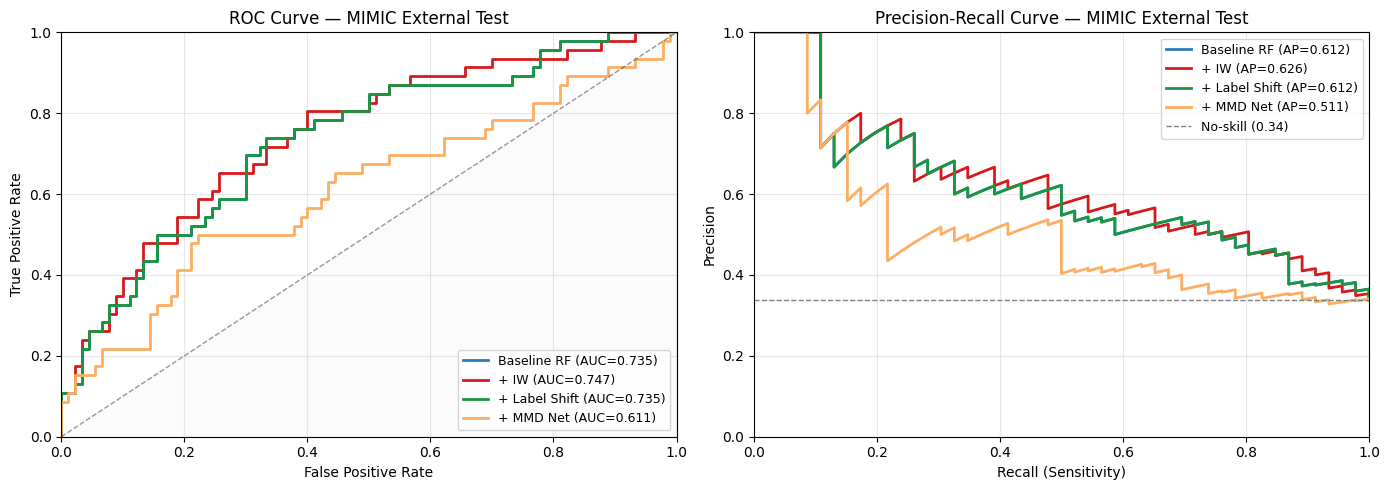

Saved to documents/roc_pr_comparison.png


In [11]:
methods = [
    ('Baseline RF',       base_probs_mimic, y_mimic),
    ('+ IW',              iw_probs_mimic,   y_mimic),
    ('+ Label Shift',     ls_probs_mimic,   y_mimic),
    ('+ MMD Net',         mmd_probs_mimic,  y_mimic),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2c7bb6', '#d7191c', '#1a9641', '#fdae61']

for (label, probs, y), color in zip(methods, colors):
    fpr, tpr, _   = roc_curve(y, probs)
    prec, rec, _  = precision_recall_curve(y, probs)
    auc  = roc_auc_score(y, probs)
    pr   = average_precision_score(y, probs)
    axes[0].plot(fpr, tpr,  color=color, lw=2, label=f'{label} (AUC={auc:.3f})')
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{label} (AP={pr:.3f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, lw=1)
axes[0].fill_between([0,1],[0,1], alpha=0.03, color='gray')
baseline_prev = y_mimic.mean()
axes[1].axhline(baseline_prev, color='gray', ls='--', lw=1, label=f'No-skill ({baseline_prev:.2f})')

for ax, xl, yl, t in zip(axes,
    ['False Positive Rate', 'Recall (Sensitivity)'],
    ['True Positive Rate', 'Precision'],
    ['ROC Curve — MIMIC External Test', 'Precision-Recall Curve — MIMIC External Test']):
    ax.set(xlabel=xl, ylabel=yl, title=t, xlim=[0,1], ylim=[0,1])
    ax.legend(fontsize=9, loc='lower right' if 'ROC' in t else 'upper right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI in Medicine/documents/roc_pr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to documents/roc_pr_comparison.png')

## 4. Bar Chart — Metrics Comparison Across Methods

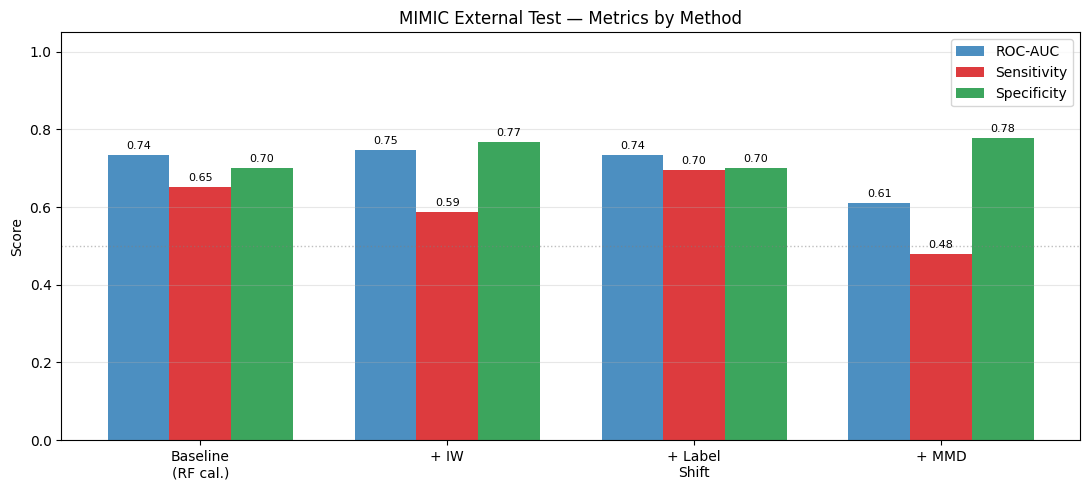

In [12]:
labels  = ['Baseline\n(RF cal.)', '+ IW', '+ Label\nShift', '+ MMD']
roc_vals  = [roc_auc_score(y_mimic, p) for p in [base_probs_mimic, iw_probs_mimic, ls_probs_mimic, mmd_probs_mimic]]

def sens_spec(probs, y, thr):
    preds = (probs >= thr).astype(int)
    cm = confusion_matrix(y, preds)
    tn, fp, fn, tp = cm.ravel()
    return tp/(tp+fn), tn/(tn+fp)

thresholds   = [eicu_thr, iw_thr, mimic_thr, 0.5]
sens_vals, spec_vals = zip(*[sens_spec(p, y_mimic, t) for p, t in zip(
    [base_probs_mimic, iw_probs_mimic, ls_probs_mimic, mmd_probs_mimic], thresholds)])

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width, roc_vals,  width, label='ROC-AUC',     color='#2c7bb6', alpha=0.85)
bars2 = ax.bar(x,         sens_vals, width, label='Sensitivity',  color='#d7191c', alpha=0.85)
bars3 = ax.bar(x + width, spec_vals, width, label='Specificity',  color='#1a9641', alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('MIMIC External Test — Metrics by Method')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI in Medicine/documents/metrics_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Calibration Plots — Before and After Label Shift Correction

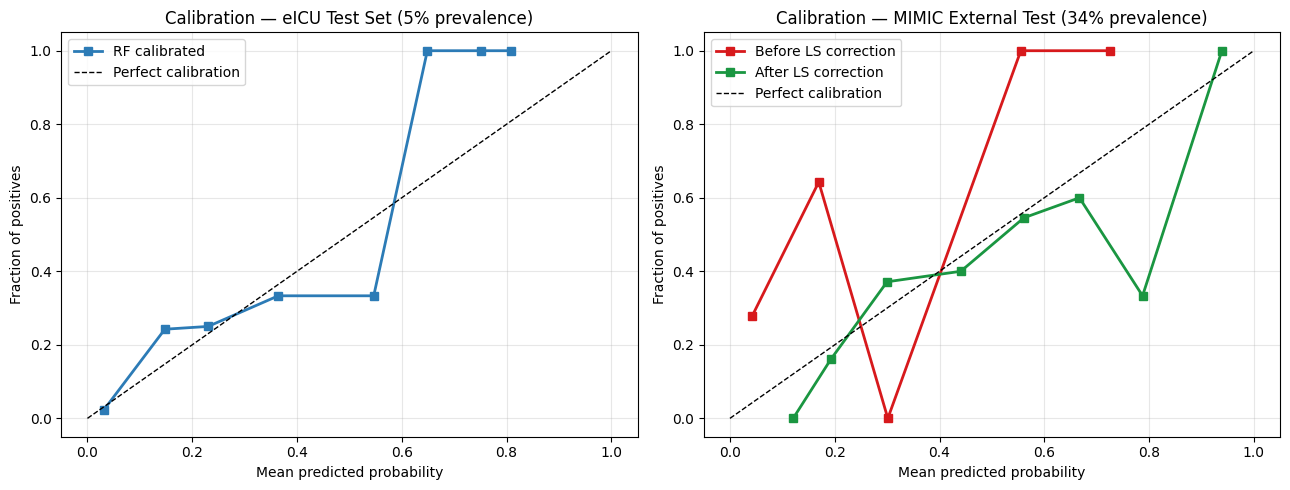

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# eICU test — baseline calibration
frac_pos, mean_pred = calibration_curve(y_test, base_probs_test, n_bins=10)
axes[0].plot(mean_pred, frac_pos, 's-', color='#2c7bb6', lw=2, label='RF calibrated')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Perfect calibration')
axes[0].set(title='Calibration — eICU Test Set (5% prevalence)',
            xlabel='Mean predicted probability', ylabel='Fraction of positives')
axes[0].legend(); axes[0].grid(alpha=0.3)

# MIMIC — before and after label shift
frac_raw,  mean_raw  = calibration_curve(y_mimic, base_probs_mimic, n_bins=8)
frac_corr, mean_corr = calibration_curve(y_mimic, ls_probs_mimic,   n_bins=8)
axes[1].plot(mean_raw,  frac_raw,  's-', color='#d7191c', lw=2, label='Before LS correction')
axes[1].plot(mean_corr, frac_corr, 's-', color='#1a9641', lw=2, label='After LS correction')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Perfect calibration')
axes[1].set(title='Calibration — MIMIC External Test (34% prevalence)',
            xlabel='Mean predicted probability', ylabel='Fraction of positives')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI in Medicine/documents/calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Confusion Matrices — All Methods on MIMIC

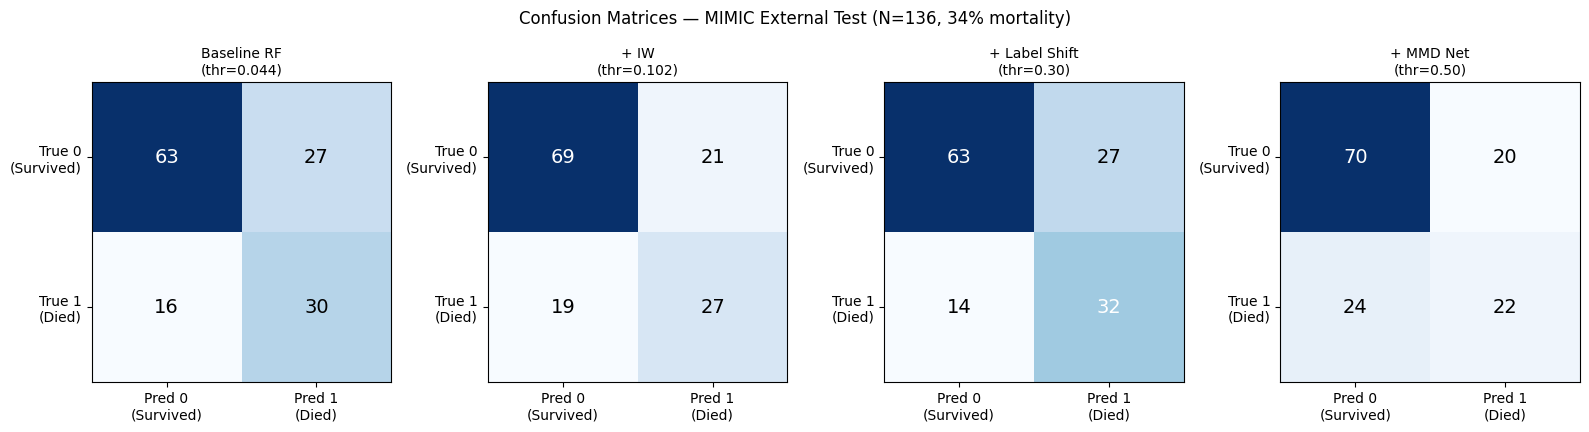

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

method_data = [
    ('Baseline RF\n(thr=0.044)',      base_probs_mimic, eicu_thr),
    ('+ IW\n(thr={:.3f})'.format(iw_thr), iw_probs_mimic, iw_thr),
    ('+ Label Shift\n(thr=0.30)',     ls_probs_mimic,  mimic_thr),
    ('+ MMD Net\n(thr=0.50)',         mmd_probs_mimic, 0.5),
]

for ax, (title, probs, thr) in zip(axes, method_data):
    preds = (probs >= thr).astype(int)
    cm = confusion_matrix(y_mimic, preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred 0\n(Survived)', 'Pred 1\n(Died)'])
    ax.set_yticklabels(['True 0\n(Survived)', 'True 1\n(Died)'])
    ax.set_title(title, fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=14, color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.suptitle('Confusion Matrices — MIMIC External Test (N=136, 34% mortality)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI in Medicine/documents/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. SHAP Feature Importance

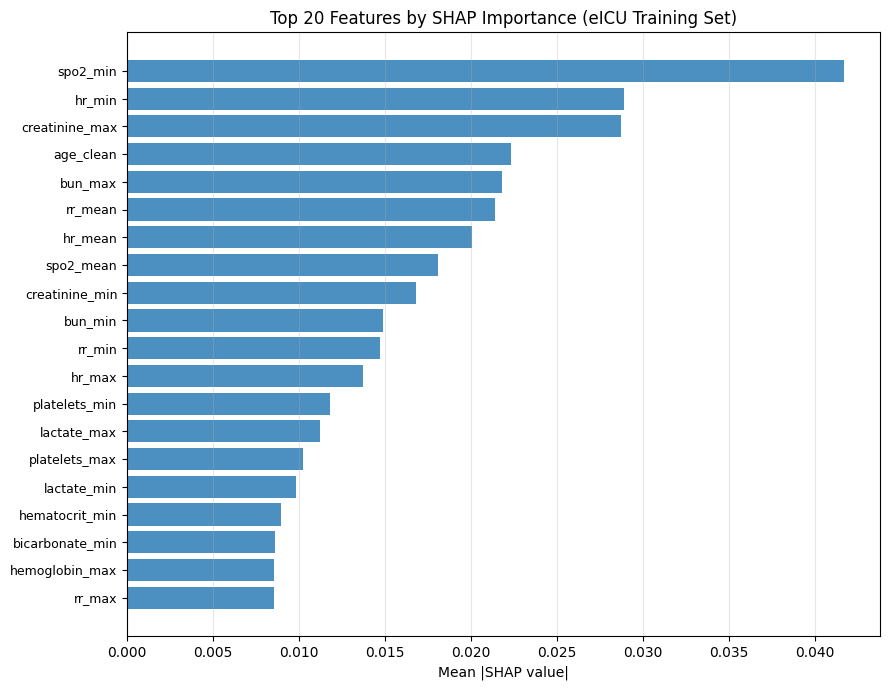

In [15]:
# Use the underlying RF estimator from calibrated model
base_rf = rf_cal.calibrated_classifiers_[0].estimator

explainer   = shap.TreeExplainer(base_rf)
shap_values = explainer.shap_values(X_train.iloc[:500])

# Handle different shap_values shapes across sklearn/shap versions
if isinstance(shap_values, list):
    sv = shap_values[1]          # binary: take class-1 array (n_samples, n_features)
else:
    sv = np.array(shap_values)
    if sv.ndim == 3:             # (n_samples, n_features, n_classes)
        sv = sv[:, :, 1]
    elif sv.ndim == 2:
        pass                     # already (n_samples, n_features)

# Now sv is 2D: (n_samples, n_features)
mean_abs     = np.abs(sv).mean(axis=0)          # shape: (n_features,)
top_idx      = np.argsort(mean_abs)[-20:][::-1] # shape: (20,)
top_features = X_train.columns.to_numpy()[top_idx]
top_vals     = mean_abs[top_idx]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(20), top_vals[::-1], color='#2c7bb6', alpha=0.85)
ax.set_yticks(range(20))
ax.set_yticklabels(top_features[::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 Features by SHAP Importance (eICU Training Set)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI in Medicine/documents/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Subgroup Performance Breakdown

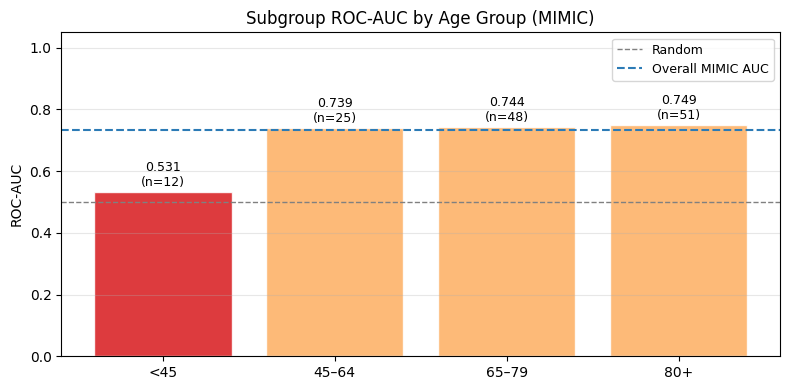

Age Group  N Mortality  ROC-AUC
      <45 12       67%    0.531
    45–64 25        8%    0.739
    65–79 48       23%    0.744
      80+ 51       49%    0.749


In [16]:
# ── Age group subgroups
mimic_raw = pd.read_csv(f'/content/drive/MyDrive/AI in Medicine/data/output_data/mimic_val/mimic_features.csv')
age_col   = next((c for c in mimic_raw.columns if 'age' in c.lower()), None)

if age_col and len(mimic_raw) == len(X_mimic):
    ages = mimic_raw[age_col].values
    age_groups = [
        ('<45',   ages < 45),
        ('45–64', (ages >= 45) & (ages < 65)),
        ('65–79', (ages >= 65) & (ages < 80)),
        ('80+',   ages >= 80),
    ]
    records = []
    for name, mask in age_groups:
        if mask.sum() < 5 or y_mimic[mask].sum() < 2:
            continue
        auc  = roc_auc_score(y_mimic[mask], base_probs_mimic[mask])
        n    = mask.sum()
        prev = y_mimic[mask].mean()
        records.append({'Age Group': name, 'N': n, 'Mortality': f'{prev:.0%}', 'ROC-AUC': round(auc, 3)})
    df_age = pd.DataFrame(records)

    fig, ax = plt.subplots(figsize=(8, 4))
    colors_age = ['#d7191c' if v < 0.65 else '#fdae61' if v < 0.75 else '#1a9641'
                  for v in df_age['ROC-AUC']]
    ax.bar(df_age['Age Group'], df_age['ROC-AUC'], color=colors_age, alpha=0.85, edgecolor='white')
    for i, (_, row) in enumerate(df_age.iterrows()):
        ax.text(i, row['ROC-AUC'] + 0.01, f"{row['ROC-AUC']}\n(n={row['N']})",
                ha='center', va='bottom', fontsize=9)
    ax.axhline(0.5, color='gray', ls='--', lw=1, label='Random')
    ax.axhline(roc_auc_score(y_mimic, base_probs_mimic), color='#2c7bb6', ls='--', lw=1.5, label='Overall MIMIC AUC')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('ROC-AUC'); ax.set_title('Subgroup ROC-AUC by Age Group (MIMIC)')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/AI in Medicine/documents/subgroup_age_auc.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(df_age.to_string(index=False))
else:
    print(f'Age column not found. Available columns: {list(mimic_raw.columns[:10])}')

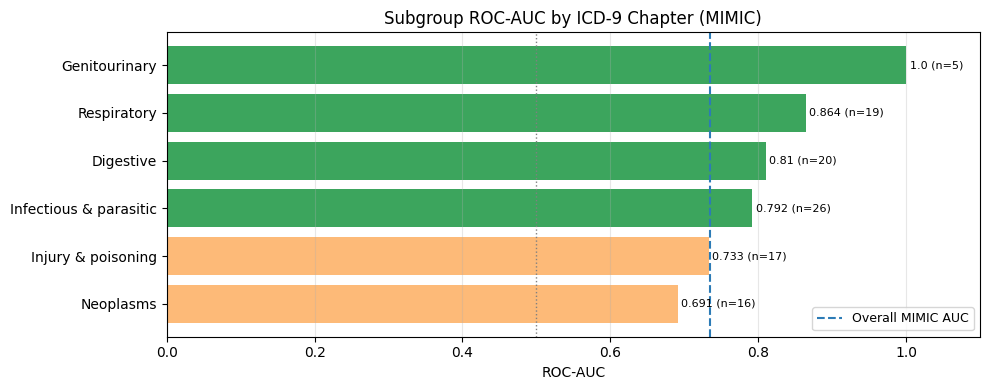

         ICD-9 Chapter  N Mortality  ROC-AUC
             Neoplasms 16       31%    0.691
    Injury & poisoning 17       29%    0.733
Infectious & parasitic 26       23%    0.792
             Digestive 20       50%    0.810
           Respiratory 19       42%    0.864
         Genitourinary  5       40%    1.000


In [17]:
# ── ICD-9 chapter subgroups (one-hot columns in X_mimic)
icd_cols = [c for c in X_mimic.columns if c.startswith('icd9_chapter_')]
records  = []
for col in icd_cols:
    mask = X_mimic[col].values == 1
    if mask.sum() < 5 or y_mimic[mask].sum() < 2:
        continue
    auc  = roc_auc_score(y_mimic[mask], base_probs_mimic[mask])
    n    = mask.sum()
    prev = y_mimic[mask].mean()
    name = col.replace('icd9_chapter_', '')
    records.append({'ICD-9 Chapter': name, 'N': n, 'Mortality': f'{prev:.0%}', 'ROC-AUC': round(auc, 3)})

df_icd = pd.DataFrame(records).sort_values('ROC-AUC')

fig, ax = plt.subplots(figsize=(10, max(4, len(df_icd)*0.45)))
colors_icd = ['#d7191c' if v < 0.65 else '#fdae61' if v < 0.75 else '#1a9641'
               for v in df_icd['ROC-AUC']]
ax.barh(df_icd['ICD-9 Chapter'], df_icd['ROC-AUC'], color=colors_icd, alpha=0.85)
ax.axvline(roc_auc_score(y_mimic, base_probs_mimic), color='#2c7bb6', ls='--', lw=1.5, label='Overall MIMIC AUC')
ax.axvline(0.5, color='gray', ls=':', lw=1)
for i, (_, row) in enumerate(df_icd.iterrows()):
    ax.text(row['ROC-AUC'] + 0.005, i, f"{row['ROC-AUC']} (n={row['N']})", va='center', fontsize=8)
ax.set_xlim(0, 1.1)
ax.set_xlabel('ROC-AUC'); ax.set_title('Subgroup ROC-AUC by ICD-9 Chapter (MIMIC)')
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI in Medicine/documents/subgroup_icd9_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_icd.to_string(index=False))

## 9. Bootstrap Confidence Intervals — MIMIC External Test

With only 136 patients, point-estimate metrics have wide uncertainty. We use 1,000-sample bootstrap resampling to compute 95% confidence intervals on ROC-AUC, Sensitivity, and Specificity for all four methods.

In [18]:
def bootstrap_ci(probs, y_true, threshold, n_bootstrap=1000, seed=42):
    """
    Returns point estimates + 95% bootstrap CIs for ROC-AUC, Sensitivity, Specificity.
    Resamples with replacement n_bootstrap times; skips degenerate draws.
    """
    rng   = np.random.default_rng(seed)
    n     = len(y_true)
    y_arr = np.array(y_true)
    p_arr = np.array(probs)

    aucs, sens_list, spec_list = [], [], []

    for _ in range(n_bootstrap):
        idx   = rng.integers(0, n, size=n)
        y_b   = y_arr[idx]
        p_b   = p_arr[idx]

        # skip resamples with no positive or no negative cases
        if y_b.sum() < 2 or (1 - y_b).sum() < 2:
            continue

        aucs.append(roc_auc_score(y_b, p_b))

        preds = (p_b >= threshold).astype(int)
        cm    = confusion_matrix(y_b, preds)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            sens_list.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
            spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)

    def ci95(arr):
        arr = np.array(arr, dtype=float)
        arr = arr[~np.isnan(arr)]
        return np.percentile(arr, 2.5), np.percentile(arr, 97.5)

    # Point estimates from full data
    preds_full = (p_arr >= threshold).astype(int)
    cm_full    = confusion_matrix(y_arr, preds_full)
    tn0, fp0, fn0, tp0 = cm_full.ravel() if cm_full.shape == (2,2) else (0,0,0,int(y_arr.sum()))

    auc_lo,  auc_hi  = ci95(aucs)
    sens_lo, sens_hi = ci95(sens_list)
    spec_lo, spec_hi = ci95(spec_list)

    return {
        'auc':  roc_auc_score(y_arr, p_arr),
        'auc_ci':  (auc_lo,  auc_hi),
        'sens': tp0 / (tp0 + fn0) if (tp0 + fn0) > 0 else 0.0,
        'sens_ci': (sens_lo, sens_hi),
        'spec': tn0 / (tn0 + fp0) if (tn0 + fp0) > 0 else 0.0,
        'spec_ci': (spec_lo, spec_hi),
    }


# ── Run bootstrap for all four methods ───────────────────────────────────────
method_configs = [
    ('Baseline RF',   base_probs_mimic, eicu_thr),
    ('+ IW',          iw_probs_mimic,   iw_thr),
    ('+ Label Shift', ls_probs_mimic,   mimic_thr),
    ('+ MMD Net',     mmd_probs_mimic,  0.5),
]

print('Running 1,000-sample bootstrap (this takes ~10 seconds)...')
results = {name: bootstrap_ci(probs, y_mimic, thr) for name, probs, thr in method_configs}
print('Done.\n')

# ── Print formatted table ─────────────────────────────────────────────────────
header = f"{'Method':<18s}  {'ROC-AUC':>8s}  {'95% CI':>13s}  {'Sensitivity':>12s}  {'95% CI':>13s}  {'Specificity':>12s}  {'95% CI':>13s}"
print(header)
print('-' * len(header))
for name, r in results.items():
    print(
        f"{name:<18s}  "
        f"{r['auc']:>8.3f}  "
        f"({r['auc_ci'][0]:.3f}–{r['auc_ci'][1]:.3f})  "
        f"{r['sens']:>12.3f}  "
        f"({r['sens_ci'][0]:.3f}–{r['sens_ci'][1]:.3f})  "
        f"{r['spec']:>12.3f}  "
        f"({r['spec_ci'][0]:.3f}–{r['spec_ci'][1]:.3f})"
    )

Running 1,000-sample bootstrap (this takes ~10 seconds)...
Done.

Method               ROC-AUC         95% CI   Sensitivity         95% CI   Specificity         95% CI
-----------------------------------------------------------------------------------------------------
Baseline RF            0.735  (0.642–0.823)         0.652  (0.519–0.791)         0.700  (0.602–0.793)
+ IW                   0.747  (0.656–0.831)         0.587  (0.442–0.731)         0.767  (0.681–0.853)
+ Label Shift          0.735  (0.642–0.823)         0.696  (0.568–0.829)         0.700  (0.602–0.793)
+ MMD Net              0.611  (0.510–0.711)         0.478  (0.339–0.634)         0.778  (0.685–0.863)


## 10. SHAP on MIMIC — Feature Importance Shift vs eICU

SHAP (SHapley Additive exPlanations) measures how much each feature contributed to each individual prediction. The **mean absolute SHAP value** across all patients is a model-agnostic feature importance score.

We already computed SHAP on the eICU training set (Section 7). Here we compute it again on the **MIMIC external test set** and compare the two rankings side by side.

**Why this matters:** The gap analysis found that SBP/DBP/MAP were 84% missing in eICU training, so the model learned near-zero weights for blood pressure. In MIMIC, BP is measured on 97% of patients. If the model truly cannot use BP, those features should have low SHAP values on MIMIC too — even though real BP values are present. This comparison directly tests that hypothesis.

Features that **rise in rank** on MIMIC but were unimportant in eICU suggest signal the model is under-exploiting. Features that **fall in rank** suggest the model over-relies on something that does not generalise.

In [20]:
# ── Initialise SHAP explainer (safe to re-run even if Section 7 already ran) ──
base_rf   = rf_cal.calibrated_classifiers_[0].estimator
explainer = shap.TreeExplainer(base_rf)

# eICU SHAP — 500 training samples for speed
shap_eicu_raw = explainer.shap_values(X_train.iloc[:500])
if isinstance(shap_eicu_raw, list):
    sv_eicu = shap_eicu_raw[1]
else:
    sv_eicu = np.array(shap_eicu_raw)
    if sv_eicu.ndim == 3:
        sv_eicu = sv_eicu[:, :, 1]

# MIMIC SHAP — all 136 patients
shap_mimic_raw = explainer.shap_values(X_mimic)
if isinstance(shap_mimic_raw, list):
    sv_mimic = shap_mimic_raw[1]
else:
    sv_mimic = np.array(shap_mimic_raw)
    if sv_mimic.ndim == 3:
        sv_mimic = sv_mimic[:, :, 1]

# Mean absolute SHAP per feature
mean_eicu  = pd.Series(np.abs(sv_eicu).mean(axis=0),  index=X_train.columns)
mean_mimic = pd.Series(np.abs(sv_mimic).mean(axis=0), index=X_mimic.columns)

# Build comparison dataframe — top 20 by union of both rankings
top_eicu    = set(mean_eicu.nlargest(20).index)
top_mimic   = set(mean_mimic.nlargest(20).index)
union_feats = list(top_eicu | top_mimic)

shap_df = pd.DataFrame({
    'eICU (train)': mean_eicu[union_feats],
    'MIMIC (ext.)': mean_mimic[union_feats],
}).sort_values('eICU (train)', ascending=False)

# Rank each feature — convert to plain Python int to avoid float formatting errors
rank_eicu  = mean_eicu.rank(ascending=False).astype(int)
rank_mimic = mean_mimic.rank(ascending=False).astype(int)
shap_df['rank_eicu']  = rank_eicu[union_feats].values
shap_df['rank_mimic'] = rank_mimic[union_feats].values
shap_df['rank_delta'] = shap_df['rank_eicu'] - shap_df['rank_mimic']

print('Top features — SHAP importance in eICU training vs MIMIC external test:')
print(f"{'Feature':<28s}  {'eICU SHAP':>10s}  {'MIMIC SHAP':>11s}  {'eICU rank':>10s}  {'MIMIC rank':>11s}  {'Δ rank':>7s}")
print('-' * 85)
for feat, row in shap_df.iterrows():
    re = int(row['rank_eicu'])
    rm = int(row['rank_mimic'])
    rd = int(row['rank_delta'])
    flag = '  ↑ rose in MIMIC' if rd > 5 else ('  ↓ fell in MIMIC' if rd < -5 else '')
    print(f"{feat:<28s}  {row['eICU (train)']:>10.4f}  {row['MIMIC (ext.)']:>11.4f}"
          f"  {re:>10d}  {rm:>11d}  {rd:>+7d}{flag}")


Top features — SHAP importance in eICU training vs MIMIC external test:
Feature                        eICU SHAP   MIMIC SHAP   eICU rank   MIMIC rank   Δ rank
-------------------------------------------------------------------------------------
spo2_min                          0.0417       0.0409           3            2       +1
hr_min                            0.0289       0.0249          15           10       +5
creatinine_max                    0.0287       0.0357           6            6       +0
age_clean                         0.0223       0.0153          22           17       +5
bun_max                           0.0218       0.0230           5            4       +1
rr_mean                           0.0214       0.0219           9            5       +4
hr_mean                           0.0201       0.0175          12           14       -2
spo2_mean                         0.0181       0.0170          28           13      +15  ↑ rose in MIMIC
creatinine_min                   

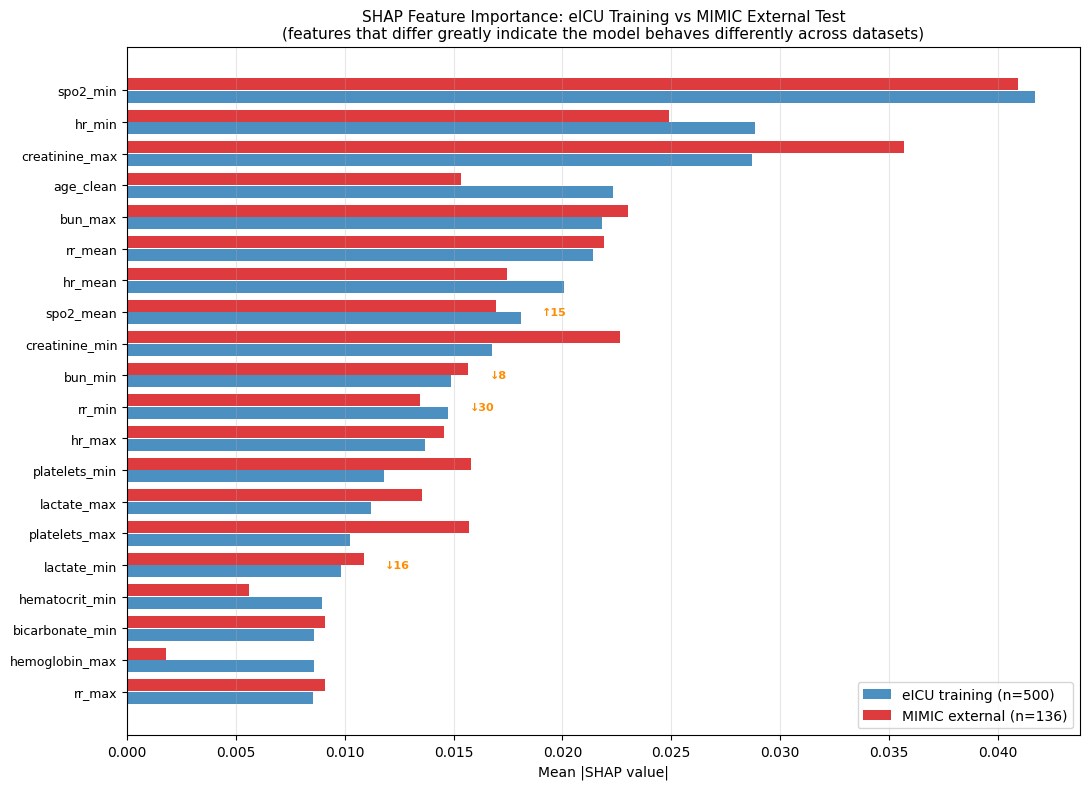

Saved to documents/shap_eicu_vs_mimic.png

── Interpretation ──
Features that rose in rank on MIMIC (model uses them more on external data):
  spo2_mean                     eICU rank  28 → MIMIC rank  13  (Δ=+15)
Features that fell in rank on MIMIC (model relies on them less externally):
  rr_min                        eICU rank  19 → MIMIC rank  49  (Δ=-30)
  lactate_min                   eICU rank  17 → MIMIC rank  33  (Δ=-16)
  bun_min                       eICU rank   4 → MIMIC rank  12  (Δ=-8)


In [23]:
# ── Side-by-side SHAP bar chart: eICU vs MIMIC ───────────────────────────────
plot_df = shap_df.head(20)
feats   = plot_df.index.tolist()[::-1]   # reverse so top feature is at top of chart
e_vals  = plot_df.loc[feats[::-1], 'eICU (train)'].values[::-1]
m_vals  = plot_df.loc[feats[::-1], 'MIMIC (ext.)'].values[::-1]

y = np.arange(len(feats))
fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(y - 0.2, e_vals, 0.38, label='eICU training (n=500)', color='#2c7bb6', alpha=0.85)
ax.barh(y + 0.2, m_vals, 0.38, label='MIMIC external (n=136)', color='#d7191c', alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(feats, fontsize=9)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance: eICU Training vs MIMIC External Test\n'
             '(features that differ greatly indicate the model behaves differently across datasets)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Annotate features with large rank shifts
for i, feat in enumerate(feats):
    delta = int(shap_df.loc[feat, 'rank_delta']) if feat in shap_df.index else 0
    if abs(delta) > 5:
        arrow = '↑' if delta > 0 else '↓'
        ax.annotate(f'{arrow}{abs(delta)}',
                    xy=(max(e_vals[i], m_vals[i]) + 0.001, i),
                    fontsize=8, color='darkorange', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI in Medicine/documents/shap_eicu_vs_mimic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to documents/shap_eicu_vs_mimic.png')

# ── Interpretation summary ────────────────────────────────────────────────────
print('\n── Interpretation ──')
rose = shap_df[shap_df['rank_delta'] > 5].sort_values('rank_delta', ascending=False)
fell = shap_df[shap_df['rank_delta'] < -5].sort_values('rank_delta')
if not rose.empty:
    print('Features that rose in rank on MIMIC (model uses them more on external data):')
    for f, r in rose.iterrows():
        print(f'  {f:<28s}  eICU rank {int(r["rank_eicu"]):>3d} → MIMIC rank {int(r["rank_mimic"]):>3d}  (Δ={int(r["rank_delta"]):+d})')
if not fell.empty:
    print('Features that fell in rank on MIMIC (model relies on them less externally):')
    for f, r in fell.iterrows():
        print(f'  {f:<28s}  eICU rank {int(r["rank_eicu"]):>3d} → MIMIC rank {int(r["rank_mimic"]):>3d}  (Δ={int(r["rank_delta"]):+d})')

## 11. Decision Curve Analysis — Clinical Utility

ROC-AUC tells you how well the model ranks patients, but it does not tell you whether using the model actually helps patients. **Decision Curve Analysis (DCA)** answers: *at what risk threshold should a clinician act on this model, and is that better than treating everyone or no one?*

### How to read a DCA plot

The x-axis is the **probability threshold** a clinician uses to decide whether to intervene (e.g., "I will treat everyone the model scores ≥ 30% mortality risk").

The y-axis is **net benefit** — a single number that weights true positives (lives saved by acting) against false positives (unnecessary interventions), using the threshold itself as the exchange rate.

- **Treat all** (dashed grey): intervene on every patient regardless of the model. This is the baseline a doctor would use if they had no model at all.
- **Treat none** (flat line at 0): never intervene. Net benefit = 0 by definition.
- **A model is clinically useful** at threshold *t* if its net benefit curve is **above both** the treat-all and treat-none lines at that threshold.

The region where a model curve sits above both baselines defines the **range of thresholds where the model adds clinical value.**

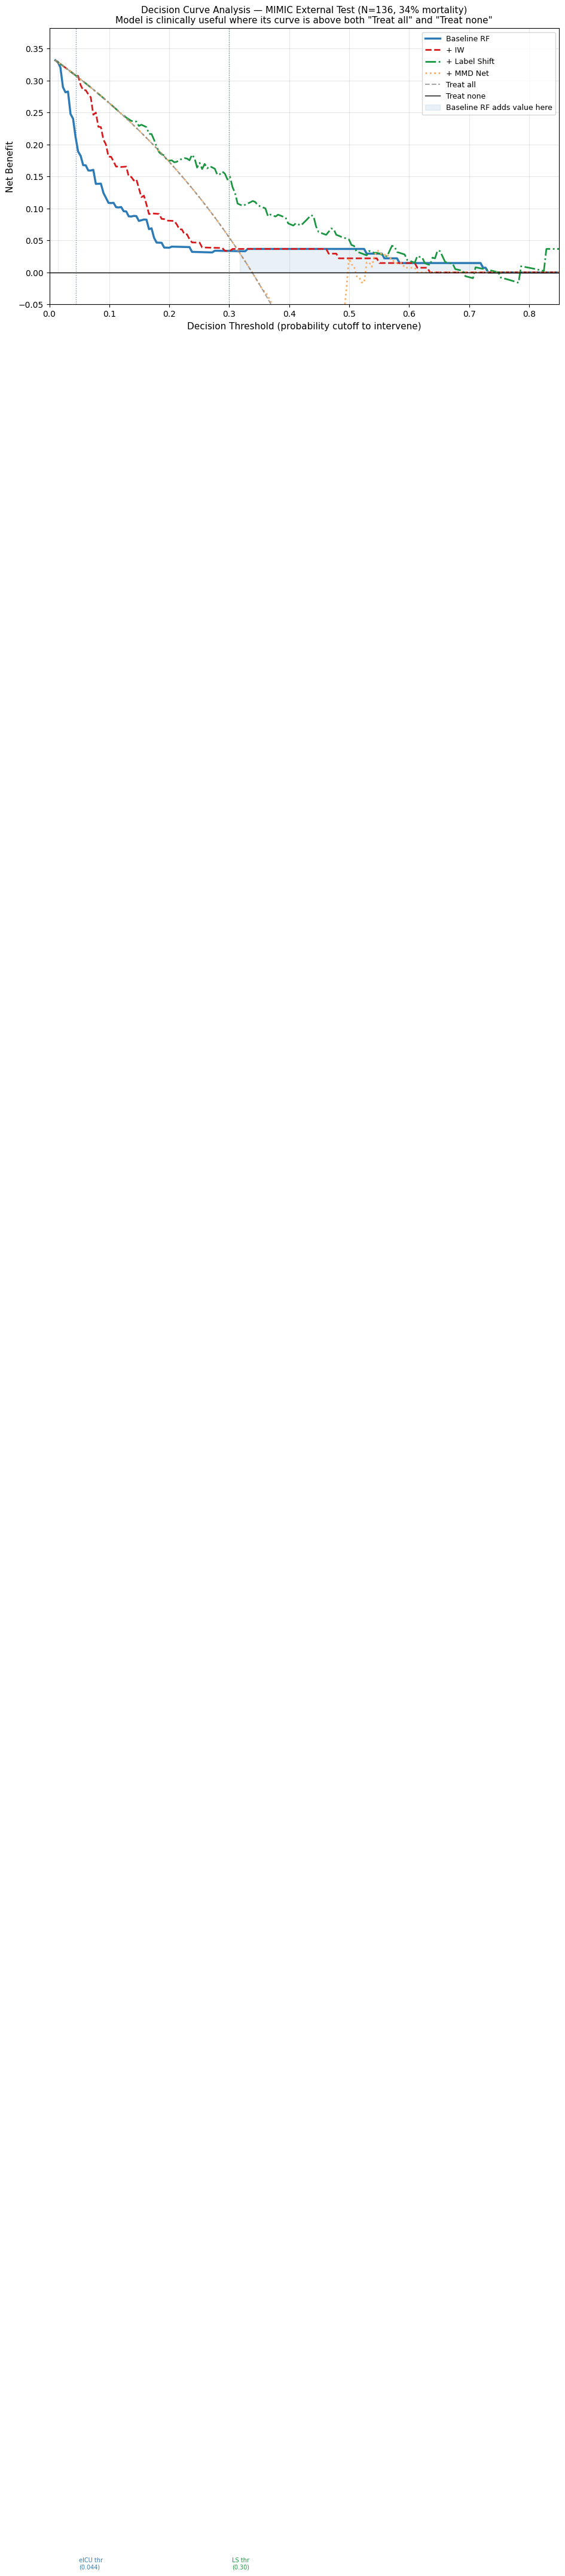

Saved to documents/decision_curve_analysis.png

Baseline RF adds net benefit over "treat all" between thresholds 0.01 and 0.73.
Outside this range, a clinician would do as well or better by treating everyone.


In [24]:
def net_benefit(probs, y_true, thresholds):
    """
    Net benefit at each threshold t:
        NB(t) = TP/N - FP/N * t/(1-t)
    where N is total patients, TP and FP are at threshold t.
    Intuitively: true positives are good, false positives cost t/(1-t) times less.
    """
    n = len(y_true)
    y = np.array(y_true)
    nb = []
    for t in thresholds:
        if t >= 1.0:
            nb.append(np.nan)
            continue
        preds = (np.array(probs) >= t).astype(int)
        tp = ((preds == 1) & (y == 1)).sum()
        fp = ((preds == 1) & (y == 0)).sum()
        nb.append(tp / n - fp / n * (t / (1 - t)))
    return np.array(nb)

def treat_all_nb(y_true, thresholds):
    """Baseline: intervene on every patient (no model needed)."""
    prev = np.array(y_true).mean()
    return np.array([prev - (1 - prev) * t / (1 - t) if t < 1 else np.nan
                     for t in thresholds])


thresholds = np.linspace(0.01, 0.85, 200)

# Compute net benefit for each method and both baselines
nb_baseline = net_benefit(base_probs_mimic, y_mimic, thresholds)
nb_iw       = net_benefit(iw_probs_mimic,   y_mimic, thresholds)
nb_ls       = net_benefit(ls_probs_mimic,   y_mimic, thresholds)
nb_mmd      = net_benefit(mmd_probs_mimic,  y_mimic, thresholds)
nb_all      = treat_all_nb(y_mimic,  thresholds)
nb_none     = np.zeros_like(thresholds)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(thresholds, nb_baseline, color='#2c7bb6', lw=2.5, label='Baseline RF')
ax.plot(thresholds, nb_iw,       color='#d7191c', lw=2,   label='+ IW',          ls='--')
ax.plot(thresholds, nb_ls,       color='#1a9641', lw=2,   label='+ Label Shift',  ls='-.')
ax.plot(thresholds, nb_mmd,      color='#fdae61', lw=2,   label='+ MMD Net',      ls=':')
ax.plot(thresholds, nb_all,      color='gray',    lw=1.5, label='Treat all',      ls='--', alpha=0.7)
ax.axhline(0, color='black', lw=1, label='Treat none')

# Shade the region where baseline RF beats both naive strategies
useful = (nb_baseline > nb_all) & (nb_baseline > 0)
if useful.any():
    ax.fill_between(thresholds, nb_baseline, 0,
                    where=useful, alpha=0.10, color='#2c7bb6',
                    label='Baseline RF adds value here')

# Mark the two operating thresholds used in this project
ax.axvline(eicu_thr,   color='#2c7bb6', lw=1, ls=':', alpha=0.8)
ax.axvline(mimic_thr,  color='#1a9641', lw=1, ls=':', alpha=0.8)
ax.text(eicu_thr  + 0.005, ax.get_ylim()[0] + 0.01, f'eICU thr\n({eicu_thr:.3f})',  fontsize=7, color='#2c7bb6')
ax.text(mimic_thr + 0.005, ax.get_ylim()[0] + 0.01, f'LS thr\n({mimic_thr:.2f})',   fontsize=7, color='#1a9641')

ax.set_xlim(0, 0.85)
ax.set_ylim(-0.05, max(nb_all[~np.isnan(nb_all)].max(), nb_baseline[~np.isnan(nb_baseline)].max()) + 0.05)
ax.set_xlabel('Decision Threshold (probability cutoff to intervene)', fontsize=11)
ax.set_ylabel('Net Benefit', fontsize=11)
ax.set_title('Decision Curve Analysis — MIMIC External Test (N=136, 34% mortality)\n'
             'Model is clinically useful where its curve is above both "Treat all" and "Treat none"', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI in Medicine/documents/decision_curve_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to documents/decision_curve_analysis.png')

# ── Print useful threshold range ──────────────────────────────────────────────
useful_thrs = thresholds[useful]
if len(useful_thrs) > 0:
    print(f'\nBaseline RF adds net benefit over "treat all" between thresholds '
          f'{useful_thrs.min():.2f} and {useful_thrs.max():.2f}.')
    print('Outside this range, a clinician would do as well or better by treating everyone.')
else:
    print('\nBaseline RF does not clearly outperform "treat all" at any threshold on this dataset.')
    print('This is consistent with the small sample and calibration mismatch at 34% prevalence.')